In [1]:
import numpy as np
import pandas as pd

# ----------------------------
# Load + basic cleaning
# ----------------------------
df = pd.read_csv("joined_output.csv", low_memory=False)

# Pick your continent/region column (you have both; use one consistently)
REGION_COL = "World region according to OWID"  # e.g., Africa, Asia, Europe, North America, South America, Oceania

# Treat common "missing" tokens as NaN (your CSV uses "NA")
missing_tokens = {"NA", "N/A", "null", "NULL", "", " ", "NaN", "nan"}
df = df.replace(list(missing_tokens), np.nan)

# Optional: strip whitespace in region strings
df[REGION_COL] = df[REGION_COL].astype("string").str.strip()

# Optional: coerce numeric columns to numbers when possible (keeps non-numeric as NaN)
non_value_cols = {"Entity", "Code", "Country Name", "Country Code", REGION_COL, "Year", "Year_1"}
value_cols = [c for c in df.columns if c not in non_value_cols]
for c in value_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ----------------------------
# 1) Row counts per continent
# ----------------------------
rows_by_continent = (
    df.groupby(REGION_COL, dropna=False)
      .size()
      .rename("n_rows")
      .sort_values(ascending=False)
)
print("\nRows by continent/region:\n", rows_by_continent)

# ----------------------------
# 2) Missing counts by variable BY continent
#    -> table: rows=continent, cols=variable, values=# missing
# ----------------------------
missing_by_continent_var = (
    df.groupby(REGION_COL)[value_cols]
      .apply(lambda g: g.isna().sum())
)

# If you want missing *rate* instead of counts:
missing_rate_by_continent_var = (
    df.groupby(REGION_COL)[value_cols]
      .apply(lambda g: g.isna().mean())
)

# Show a compact view (top variables with most missing overall)
top_k = 30
overall_missing = df[value_cols].isna().sum().sort_values(ascending=False)
top_vars = overall_missing.head(top_k).index.tolist()

print(f"\nTop {top_k} variables by missing count (overall):\n", overall_missing.head(top_k))

print(f"\nMissing COUNTS by continent for top {top_k} vars:")
print(missing_by_continent_var[top_vars].sort_index())

print(f"\nMissing RATES by continent for top {top_k} vars:")
print(missing_rate_by_continent_var[top_vars].sort_index())

# ----------------------------
# 3) “How many missing values per continent (across all variables)?”
# ----------------------------
missing_total_by_continent = (
    df.groupby(REGION_COL)[value_cols]
      .apply(lambda g: g.isna().sum().sum())
      .rename("missing_total_values")
      .sort_values(ascending=False)
)
print("\nTotal missing VALUES (all variables combined) by continent:\n", missing_total_by_continent)

# Also: how many variables are "mostly missing" within each continent?
# e.g. fraction missing > 0.8
threshold = 0.80
vars_mostly_missing_by_continent = (
    missing_rate_by_continent_var.gt(threshold).sum(axis=1).rename(f"n_vars_missing_rate_gt_{threshold}")
)
print(f"\n# Variables with missing rate > {threshold} by continent:\n", vars_mostly_missing_by_continent.sort_values(ascending=False))

# ----------------------------
# 4) Outcome-variable shortlist helpers
# ----------------------------
# A) Keep variables with at least N observations overall
min_nonmissing_overall = 0.30  # keep vars with >=30% observed overall
keep_overall = df[value_cols].notna().mean().ge(min_nonmissing_overall)
candidates_overall = keep_overall[keep_overall].index.tolist()

print(f"\nCandidate vars with >= {min_nonmissing_overall:.0%} observed overall: {len(candidates_overall)}")

# B) Keep variables with at least N observations in EACH continent (more strict)
min_nonmissing_per_continent = 0.20  # >=20% observed within each continent
nonmissing_rate_by_continent = 1 - missing_rate_by_continent_var
keep_each_continent = nonmissing_rate_by_continent.ge(min_nonmissing_per_continent).all(axis=0)
candidates_each_continent = keep_each_continent[keep_each_continent].index.tolist()

print(f"Candidate vars with >= {min_nonmissing_per_continent:.0%} observed in EVERY continent: {len(candidates_each_continent)}")

# C) Rank variables by “coverage” + “interesting cross-continent variation”
#    (simple heuristic: coverage score = overall observed rate, variation = std of continent means)
continent_means = df.groupby(REGION_COL)[value_cols].mean(numeric_only=True)
coverage = df[value_cols].notna().mean().rename("overall_observed_rate")

variation = continent_means.std(axis=0, skipna=True).rename("std_of_continent_means")
score = (coverage * 1.0 + variation.fillna(0) * 0.0)  # tweak weights if you want

rank_table = (
    pd.concat([coverage, overall_missing.rename("missing_count_overall"), variation], axis=1)
      .sort_values(by=["overall_observed_rate", "std_of_continent_means"], ascending=[False, False])
)

print("\nTop 25 vars by coverage (and then cross-continent mean variation):")
print(rank_table.head(25))

# If you want a final shortlist (example):
shortlist = rank_table.loc[candidates_each_continent].head(20)
print("\nExample shortlist (top 20 among vars with decent coverage everywhere):")
print(shortlist)

# ----------------------------
# 5) Save tables to CSV for quick browsing
# ----------------------------
missing_by_continent_var.to_csv("missing_counts_by_continent_and_variable.csv")
missing_rate_by_continent_var.to_csv("missing_rates_by_continent_and_variable.csv")
rank_table.to_csv("variable_coverage_and_variation_rank.csv")

print("\nWrote:")
print(" - missing_counts_by_continent_and_variable.csv")
print(" - missing_rates_by_continent_and_variable.csv")
print(" - variable_coverage_and_variation_rank.csv")


Rows by continent/region:
 World region according to OWID
Africa           3415
Asia             2467
North America    1474
Oceania           969
South America     766
Europe            390
<NA>              260
Name: n_rows, dtype: int64

Top 30 variables by missing count (overall):
 mean_age_first_marriage_male                9681
severe_wasting_prev_pctunder5               9671
literacy_adult_female                       9665
literacy_adult_male                         9665
literacy_adult_total                        9665
mean_age_first_marriage_female              9662
wasting_prev_pctunder5                      9661
underweight_pct_age00to05                   9659
literacy_youth_gender_parity                9654
literacy_youth_male                         9654
literacy_youth_total                        9654
nonagri_empl_pctwomen                       9638
diabetes_prev_20to79_pct                    9625
secondary_enrollment_net_male               9607
secondary_enrollment_net_fe

In [2]:
import pandas as pd
import re

# df = your DataFrame

# 1) Define "population-related" name patterns to exclude (edit as needed)
pop_patterns = [
    r'\bpop\b', r'population', r'\btotal[_\s]*pop\b', r'pop[_\s]*total',
    r'\bper[_\s]*capita\b', r'capita', r'density', r'\bhousehold\b', r'\bhh\b'
]
pop_regex = re.compile("|".join(pop_patterns), flags=re.IGNORECASE)

# 2) Compute missingness
missing_n = df.isna().sum()
missing_pct = df.isna().mean()

summary = pd.DataFrame({
    "missing_n": missing_n,
    "missing_pct": missing_pct,
    "non_missing_n": df.notna().sum(),
    "dtype": df.dtypes.astype(str),
}).sort_values(["missing_n", "missing_pct"], ascending=[True, True])

# 3) Exclude population-related columns (by column name)
summary = summary.loc[
    ~summary.index.to_series().str.contains(r"\bpop\b|_pop|pop_", case=False, regex=True)
]

# 4) Bottom 30 (least missing)
bottom_30 = summary.sort_values("missing_n").head(30)
bottom_30

,missing_n,missing_pct,non_missing_n,dtype
Entity,0,0.000000,9741,str
Year,0,0.000000,9741,int64
ODA per capita by recipient,0,0.000000,9741,float64
Code,260,0.026691,9481,str
World region according to OWID,260,0.026691,9481,string
age_dependency_ratio_young,9127,0.936967,614,float64
age_dependency_ratio,9127,0.936967,614,float64
net_migration,9127,0.936967,614,float64
age_dependency_ratio_old,9127,0.936967,614,float64
Country Code,9127,0.936967,614,str


In [3]:
bottom_30_cols = bottom_30.index.tolist()
bottom_30_cols

['Entity',
 'Year',
 'ODA per capita by recipient',
 'Code',
 'World region according to OWID',
 'age_dependency_ratio_young',
 'age_dependency_ratio',
 'net_migration',
 'age_dependency_ratio_old',
 'Country Code',
 'Country Name',
 'Year_1',
 'immunization_DPT_pct_age01to02',
 'immunization_Pol3_pct_age01',
 'GNI_percap',
 'immunization_measles_pct_age01to02',
 'immunization_BCG_pct_age01',
 'life_exp_atbirth_male',
 'sex_ratio_at_birth_mtof',
 'est_survivalto65_male_pct',
 'est_fert_rate',
 'life_exp_atbirth',
 'est_survivalto65_female_pct',
 'death_rate_per1000',
 'birth_rate_per1000',
 'mort_rate_male_adult_per1000male',
 'mort_rate_female_adult_per1000female',
 'fertility_rate_adolesc',
 'life_exp_atbirth_female',
 'num_deaths_infant']

# new regressions columns

In [4]:
import numpy as np
import statsmodels.formula.api as smf

# --- scale (t-level) ---
df["mort_rate_per100_under5"] = df["mort_rate_per1000_under5"] / 10
df["TB_death_rate_per100"] = df["TB_death_rate_per100k"] / 1000

health_cols = [
    "mort_rate_per100_under5",
    "hiv_prev_ages15to49",
    "TB_death_rate_per100",
]

df = df.rename(columns={"Entity": "country", "Year": "year"})

# --- create calendar-correct lag columns for the SCALED vars if missing ---
for lag in [1, 2]:
    lag_cols = [f"{c}_lag{lag}" for c in health_cols]
    missing_lags = [c for c in lag_cols if c not in df.columns]

    if missing_lags:
        # avoid merge collisions if partial lags already exist
        df = df.drop(columns=[c for c in lag_cols if c in df.columns])

        df_lag = df[["country", "year"] + health_cols].copy()
        df_lag["year"] = df_lag["year"] + lag
        df_lag = df_lag.rename(columns={c: f"{c}_lag{lag}" for c in health_cols})

        df = df.merge(
            df_lag[["country", "year"] + [f"{c}_lag{lag}" for c in health_cols]],
            on=["country", "year"],
            how="left",
            validate="m:1",
        )

# -------------------------
# 3) OLS (robust SEs: HC1), lag 1 and lag 2
# -------------------------
y = "oda_pc"
if y not in df.columns:
    # common alt name in your earlier notebook
    if "ODA per capita by recipient" in df.columns:
        df = df.rename(columns={"ODA per capita by recipient": "oda_pc"})
    else:
        raise KeyError("Neither oda_pc nor 'ODA per capita by recipient' found.")

for lag in [1, 2]:
    X = [f"{c}_lag{lag}" for c in health_cols]
    needed = ["country", "year", y] + X

    missing = [c for c in needed if c not in df.columns]
    if missing:
        print(f"\nLag {lag}: missing columns -> {missing}")
        continue

    reg_df = df[needed].replace([np.inf, -np.inf], np.nan).dropna()
    print(f"Observations for lag {lag}: {len(reg_df)}")

    if len(reg_df) < 150:
        print(f"Lag {lag}: too few observations ({len(reg_df)})")
        continue

    formula = f"{y} ~ {' + '.join(X)}"
    model = smf.ols(formula, data=reg_df).fit(cov_type="HC1")  # robust SEs

    print("\n" + "=" * 80)
    print(f"OLS RESULTS (ROBUST SEs: HC1) — LAG {lag}")
    print("=" * 80)
    print(model.summary())

Observations for lag 1: 191

OLS RESULTS (ROBUST SEs: HC1) — LAG 1
                            OLS Regression Results                            
Dep. Variable:                 oda_pc   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.293
Date:                Sat, 21 Feb 2026   Prob (F-statistic):             0.0795
Time:                        15:44:05   Log-Likelihood:                -1165.6
No. Observations:                 191   AIC:                             2339.
Df Residuals:                     187   BIC:                             2352.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

/var/folders/5h/bgx15mls48j0xbyc78fm5g580000gn/T/ipykernel_77562/3782255475.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["mort_rate_per100_under5"] = df["mort_rate_per1000_under5"] / 10
/var/folders/5h/bgx15mls48j0xbyc78fm5g580000gn/T/ipykernel_77562/3782255475.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["TB_death_rate_per100"] = df["TB_death_rate_per100k"] / 1000


# Visualizations

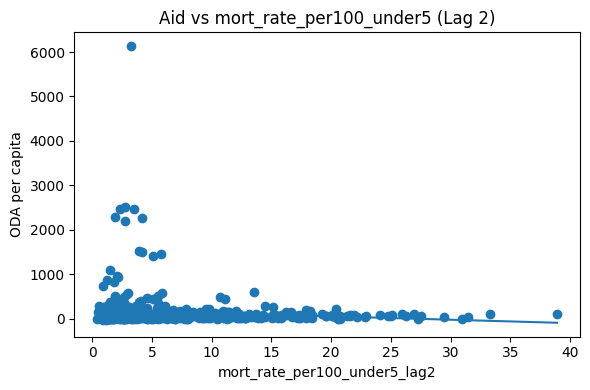

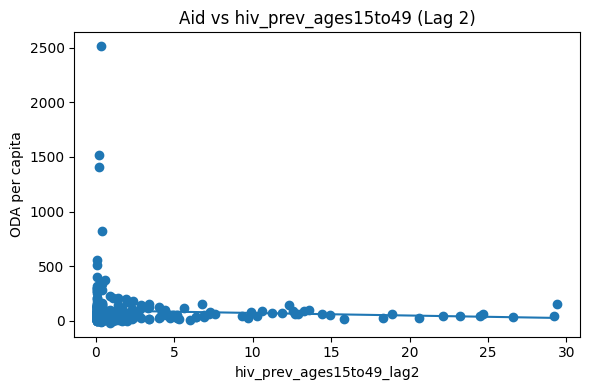

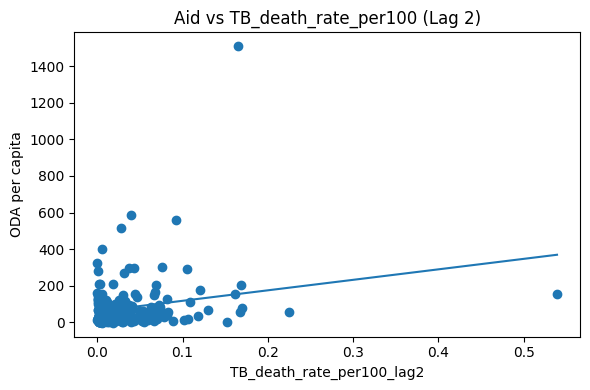

In [5]:
import matplotlib.pyplot as plt
import numpy as np

lag = 2
y = "oda_pc"

for var in health_cols:
    x = f"{var}_lag{lag}"

    if x not in df.columns:
        continue

    plot_df = df[[x, y]].dropna()

    if len(plot_df) < 50:
        continue

    plt.figure(figsize=(6,4))

    # scatter
    plt.scatter(plot_df[x], plot_df[y])

    # regression line
    m, b = np.polyfit(plot_df[x], plot_df[y], 1)
    xs = np.linspace(plot_df[x].min(), plot_df[x].max(), 100)
    plt.plot(xs, m*xs + b)

    plt.xlabel(x)
    plt.ylabel("ODA per capita")
    plt.title(f"Aid vs {var} (Lag {lag})")

    plt.tight_layout()
    plt.show()

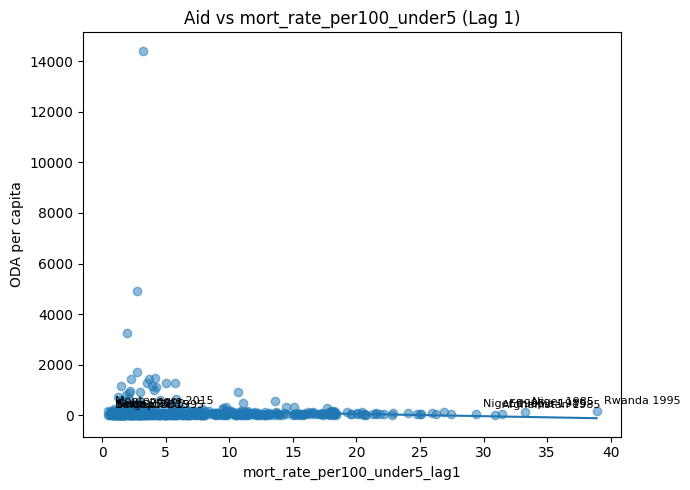

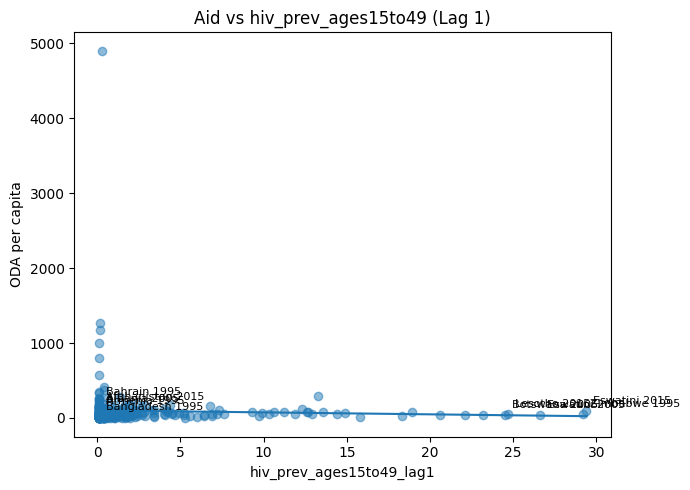

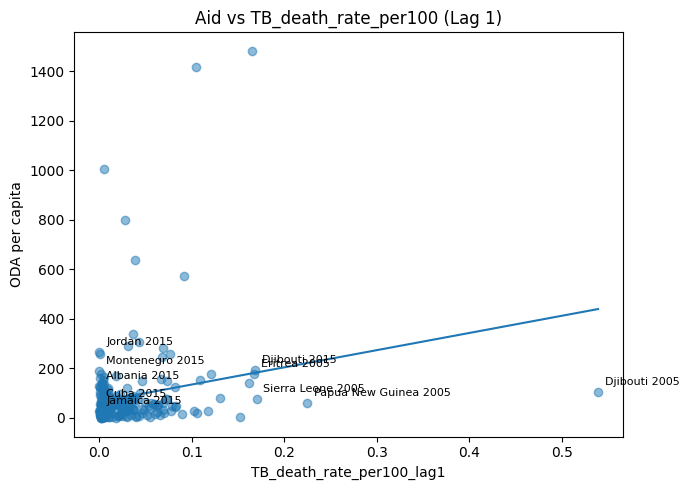

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

lag = 1
y = "oda_pc"

for var in health_cols:
    x = f"{var}_lag{lag}"
    if x not in df.columns:
        continue

    plot_df = df[["country", "year", x, y]].dropna()

    if len(plot_df) < 50:
        continue

    # pick extreme X observations
    high_x = plot_df.nlargest(5, x)
    low_x  = plot_df.nsmallest(5, x)
    label_df = pd.concat([high_x, low_x])

    plt.figure(figsize=(7,5))

    # scatter
    plt.scatter(plot_df[x], plot_df[y], alpha=0.5)

    # regression line
    m, b = np.polyfit(plot_df[x], plot_df[y], 1)
    xs = np.linspace(plot_df[x].min(), plot_df[x].max(), 100)
    plt.plot(xs, m*xs + b)

    # label extremes on X-axis
    for _, r in label_df.iterrows():
        plt.annotate(
            f"{r['country']} {int(r['year'])}",
            (r[x], r[y]),
            fontsize=8,
            xytext=(5,5),
            textcoords="offset points"
        )

    plt.xlabel(x)
    plt.ylabel("ODA per capita")
    plt.title(f"Aid vs {var} (Lag {lag})")

    plt.tight_layout()
    plt.show()

### y outliers labeled

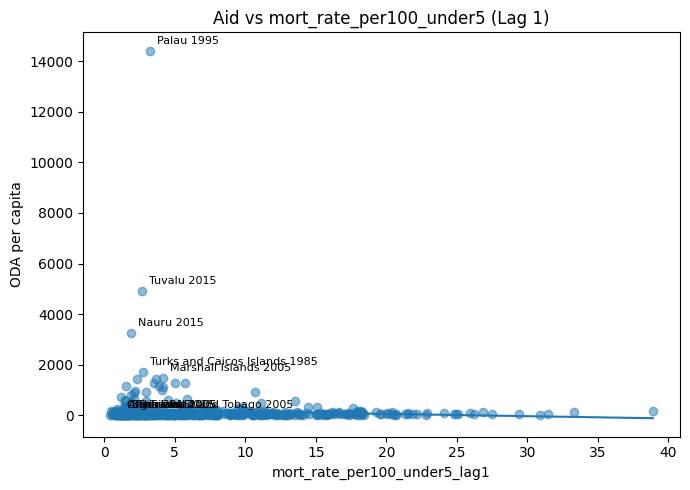

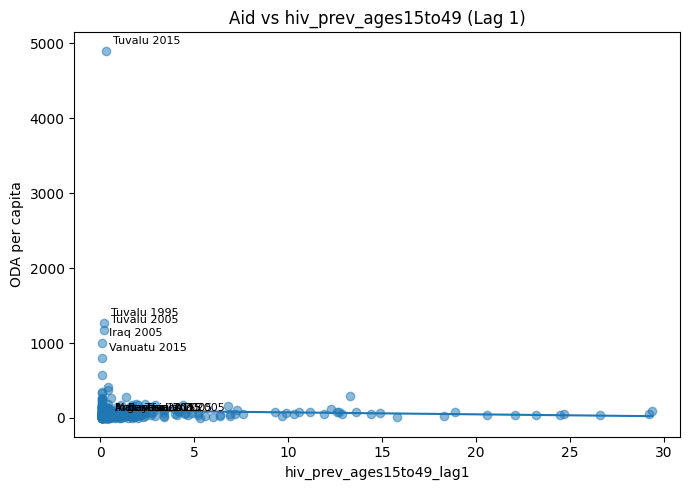

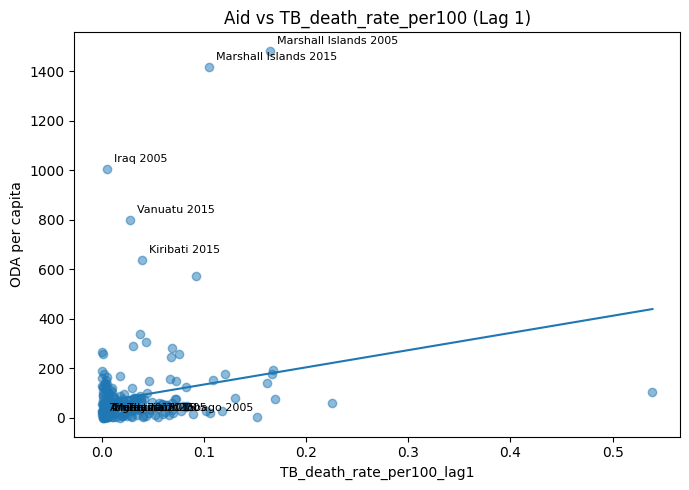

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

lag = 1
y = "oda_pc"

for var in health_cols:
    x = f"{var}_lag{lag}"
    if x not in df.columns:
        continue

    plot_df = df[["country", "year", x, y]].dropna()

    if len(plot_df) < 50:
        continue

    # pick extreme Y observations (aid)
    high_y = plot_df.nlargest(5, y)
    low_y  = plot_df.nsmallest(5, y)
    label_df = pd.concat([high_y, low_y])

    plt.figure(figsize=(7,5))

    # scatter
    plt.scatter(plot_df[x], plot_df[y], alpha=0.5)

    # regression line
    m, b = np.polyfit(plot_df[x], plot_df[y], 1)
    xs = np.linspace(plot_df[x].min(), plot_df[x].max(), 100)
    plt.plot(xs, m*xs + b)

    # label extremes on Y-axis
    for _, r in label_df.iterrows():
        plt.annotate(
            f"{r['country']} {int(r['year'])}",
            (r[x], r[y]),
            fontsize=8,
            xytext=(5,5),
            textcoords="offset points"
        )

    plt.xlabel(x)
    plt.ylabel("ODA per capita")
    plt.title(f"Aid vs {var} (Lag {lag})")

    plt.tight_layout()
    plt.show()

### prettier Viz

In [9]:
cap = df["oda_pc"].quantile(0.99)
df["oda_pc_cap"] = df["oda_pc"].clip(upper=cap)

/var/folders/5h/bgx15mls48j0xbyc78fm5g580000gn/T/ipykernel_77562/3101547745.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["oda_pc_cap"] = df["oda_pc"].clip(upper=cap)


### quartile-color-TB

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter

def scatter_quartiles_tb(
    df,
    x="mort_rate_per100_under5_lag1",
    y="oda_pc_cap",
    tb="TB_death_rate_per100_lag1",
    title="Aid vs Under-5 Mortality (Lag 1), colored by TB quartiles",
    logy=True,
):
    # keep only needed cols
    plot_df = df[["country", "year", x, y, tb]].dropna().copy()
    if len(plot_df) < 50:
        print(f"Too few rows after dropna: {len(plot_df)}")
        return

    # quartile cutoffs for TB
    q25, q50, q75 = plot_df[tb].quantile([0.25, 0.50, 0.75]).tolist()

    # bins: <=25, (25,50], (50,75], >75
    plot_df["tb_q"] = pd.cut(
        plot_df[tb],
        bins=[-np.inf, q25, q50, q75, np.inf],
        labels=["≤25th", "25–50th", "50–75th", ">75th"],
        include_lowest=True
    )

    # nicer defaults
    plt.rcParams.update({
        "figure.dpi": 140,
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    })

    fig, ax = plt.subplots(figsize=(9.5, 5.8))

    # plot in order so highest quartile sits on top
    order = ["≤25th", "25–50th", "50–75th", ">75th"]
    quartile_colors = {
        "≤25th": "#fcc5c0",
        "25–50th": "#f768a1",
        "50–75th": "#ae017e",
        ">75th": "#49006a",
    }

    for lab in order:
        sub = plot_df[plot_df["tb_q"] == lab]
        ax.scatter(
            sub[x], sub[y],
            s=24,
            alpha=0.70,
            color=quartile_colors[lab],
            edgecolors="white",
            linewidths=0.4,
            label=f"TB {lab} (n={len(sub)})"
        )

    # regression line (overall)
    m, b = np.polyfit(plot_df[x].to_numpy(), plot_df[y].to_numpy(), 1)
    xs = np.linspace(plot_df[x].min(), plot_df[x].max(), 200)
    ax.plot(xs, m*xs + b, color="black", linewidth=1.5, alpha=0.8)

    ax.set_title(title, pad=10)
    ax.set_xlabel("Under-5 mortality (per 100), lagged 1 year")
    ax.set_ylabel("ODA per capita (capped at 99th pct)")

    if logy:
        ax.set_yscale("log")
        # nicer log ticks
        ax.yaxis.set_major_locator(LogLocator(base=10.0))
        ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
        ax.yaxis.set_minor_formatter(NullFormatter())

    ax.grid(True, which="major", alpha=0.18)
    ax.grid(True, which="minor", alpha=0.08)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # legend outside to avoid covering points
    ax.legend(
        title="Tuberculosis death rate quartiles",
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
    )

    fig.tight_layout()
    plt.show()


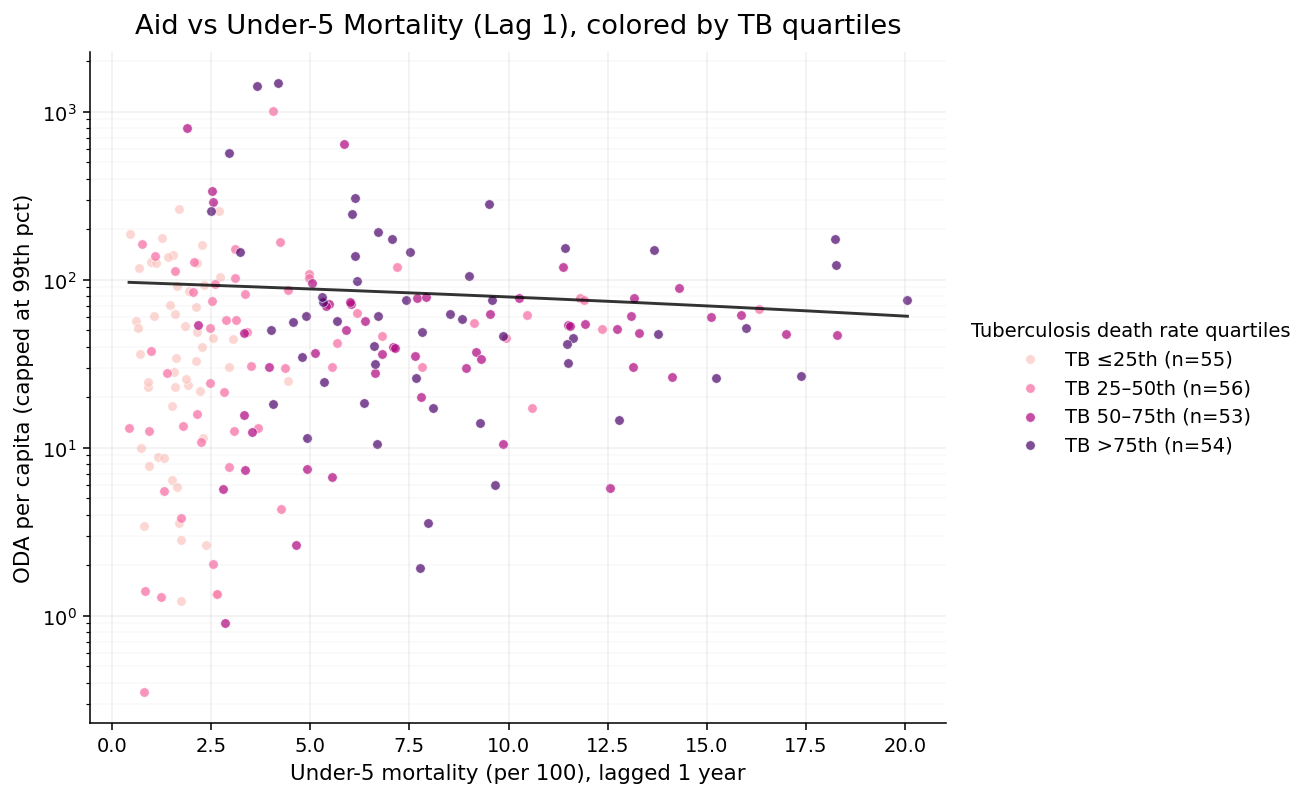

In [12]:
# run it
scatter_quartiles_tb(
    df=df,
    x="mort_rate_per100_under5_lag1",
    y="oda_pc_cap",
    tb="TB_death_rate_per100_lag1",
    title="Aid vs Under-5 Mortality (Lag 1), colored by TB quartiles",
    logy=True,
)

### Outliers Labeled (Unfinished)

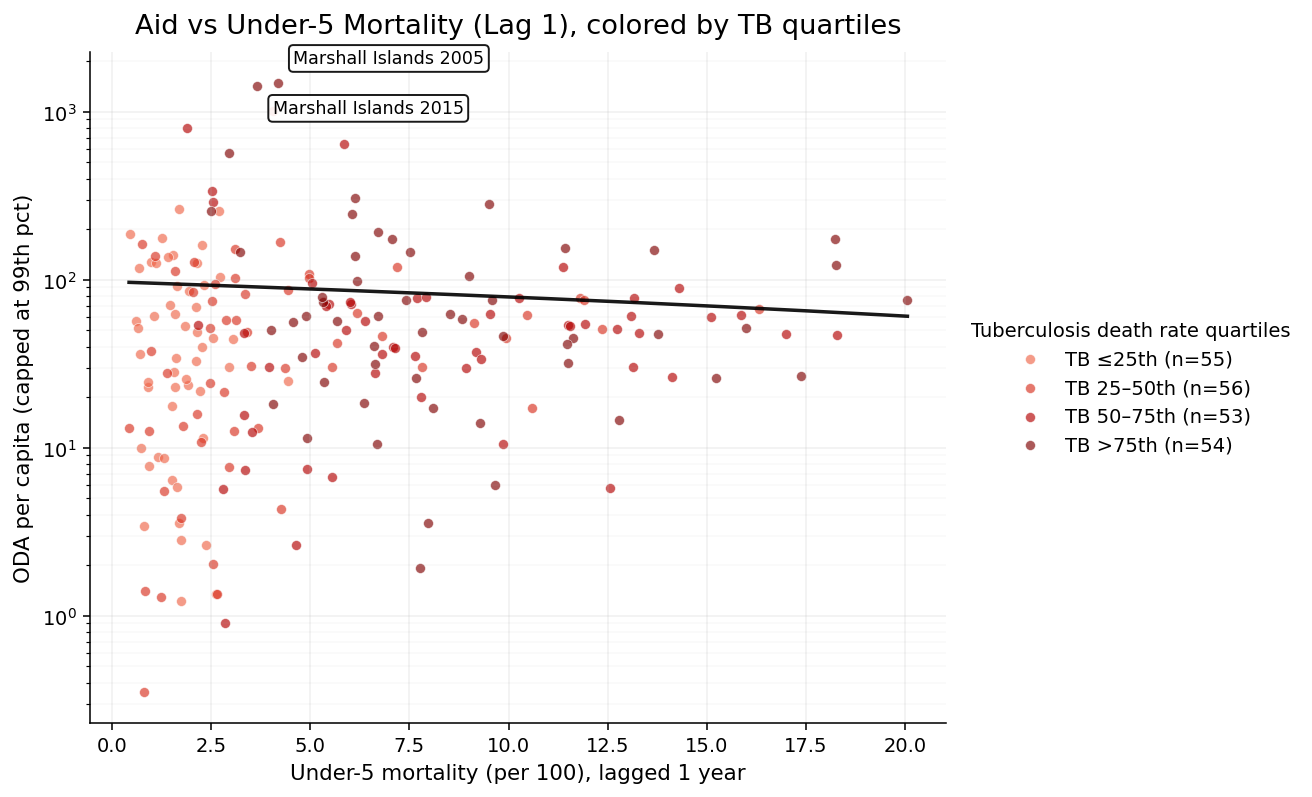

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter

def scatter_quartiles_tb_with_outliers(
    df,
    x="mort_rate_per100_under5_lag1",
    y="oda_pc_cap",
    tb="TB_death_rate_per100_lag1",
    title="Aid vs Under-5 Mortality (Lag 1), colored by TB quartiles",
    logy=True,
    n_outliers=2,          # label TOP N only (keeps it clean)
    label_bottom=False,    # set True if you also want bottom N
):
    plot_df = df[["country", "year", x, y, tb]].dropna().copy()
    if len(plot_df) < 50:
        print(f"Too few rows after dropna: {len(plot_df)}")
        return

    # TB quartiles
    q25, q50, q75 = plot_df[tb].quantile([0.25, 0.50, 0.75]).tolist()
    plot_df["tb_q"] = pd.cut(
        plot_df[tb],
        bins=[-np.inf, q25, q50, q75, np.inf],
        labels=["≤25th", "25–50th", "50–75th", ">75th"],
        include_lowest=True
    )

    plt.rcParams.update({
        "figure.dpi": 140,
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    })

    fig, ax = plt.subplots(figsize=(9.5, 5.8))

    order = ["≤25th", "25–50th", "50–75th", ">75th"]
    quartile_colors = {
        "≤25th": "#ef6548",
        "25–50th": "#d7301f",
        "50–75th": "#b30000",
        ">75th": "#7f0000",
    }

    for lab in order:
        sub = plot_df[plot_df["tb_q"] == lab]
        ax.scatter(
            sub[x], sub[y],
            s=26,
            alpha=0.65,
            color=quartile_colors[lab],
            edgecolors="white",
            linewidths=0.4,
            label=f"TB {lab} (n={len(sub)})"
        )

    # regression line
    m, b = np.polyfit(plot_df[x].to_numpy(), plot_df[y].to_numpy(), 1)
    xs = np.linspace(plot_df[x].min(), plot_df[x].max(), 200)
    ax.plot(xs, m*xs + b, color="black", linewidth=1.8, alpha=0.9)

    # -------------------------
    # Clean labeling: label only TOP N by y (optionally also bottom N),
    # no arrows/lines (avoids the “spiderweb”)
    # -------------------------
    label_df = plot_df.nlargest(n_outliers, y)
    if label_bottom:
        label_df = pd.concat([label_df, plot_df.nsmallest(n_outliers, y)]).drop_duplicates(["country", "year"])

    label_df = label_df.sort_values(y, ascending=False).reset_index(drop=True)

    # fixed offsets so labels don't overlap too much
    offsets = [(8, 10), (8, -14), (8, 18), (8, -22)]

    for i, (_, r) in enumerate(label_df.iterrows()):
        dx, dy = offsets[i % len(offsets)]
        ax.annotate(
            f"{r['country']} {int(r['year'])}",
            (r[x], r[y]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.90),
        )

    ax.set_title(title, pad=10)
    ax.set_xlabel("Under-5 mortality (per 100), lagged 1 year")
    ax.set_ylabel("ODA per capita (capped at 99th pct)")

    if logy:
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(LogLocator(base=10.0))
        ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
        ax.yaxis.set_minor_formatter(NullFormatter())

    ax.grid(True, which="major", alpha=0.18)
    ax.grid(True, which="minor", alpha=0.08)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        title="Tuberculosis death rate quartiles",
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
    )

    fig.tight_layout()
    plt.show()

# Example call (labels top 2 only):
scatter_quartiles_tb_with_outliers(
    df=df,
    x="mort_rate_per100_under5_lag1",
    y="oda_pc_cap",
    tb="TB_death_rate_per100_lag1",
    title="Aid vs Under-5 Mortality (Lag 1), colored by TB quartiles",
    logy=True,
    n_outliers=2,
    label_bottom=False
)